# Document Model Processing Graph


## Setup and Configuration


In [109]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

# Import settings
from src.config import settings

print(f"Application: {settings.app_name}")
print(f"Version: {settings.app_version}")
print(f"Default LLM Model: {settings.default_llm_model}")
print(f"Temperature: {settings.default_llm_temperature}")

Application: Data Agent LangGraph
Version: 0.1.0
Default LLM Model: gpt-4o
Temperature: 0.7


In [110]:
settings.predefined_document_models

['Invoice',
 'Receipt',
 'NRIC',
 'Bank Statements',
 'Indian Invoice',
 'Indian Receipt',
 'Aero Invoice',
 'Canadian Invoice',
 'US Invoice',
 'EMEA Invoice',
 'Statement of Accounts',
 'Pakistan Challan',
 'Bangladesh Challan',
 'Purchase Order',
 'Document Classifier',
 'Identification',
 'Fapiao Invoice',
 'Credit Card']

## Import Dependencies


In [111]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import numpy as np
from typing import Any, Optional, List

## Init LLM


In [112]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=settings.default_llm_model,
    temperature=settings.default_llm_temperature,
    api_key=settings.openai_api_key,
)

## State Definition


In [113]:
# create custom reducers

from typing import Dict

In [114]:
from typing import Dict
from src.graphs.custom_reducers.reduce_search_payload import reduce_search_payload
from src.graphs.state_definitions.overall_state import SearchPayload


class DocumentModelOverallState(TypedDict):
    # reuse channels from main graph
    messages: Annotated[list, add_messages]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload, reduce_search_payload]

    # node-specific channels
    # document models
    map_document_models_to_ids: Dict[str, str]
    extracted_document_models: List[str]
    map_extracted_document_models_to_ids: Dict[str, str]

    # document fields levels
    map_document_model_fields_to_code: Dict[str,str]
    map_fields_to_values: List[Dict[str, str]]


class DocumentModelOutputState(TypedDict):
    # reuse channels from main graph
    messages: Annotated[list, add_messages]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload, reduce_search_payload]

## Construct queue mapping node


In [115]:
import requests
import json


def construct_model_mapping(state: DocumentModelOverallState):

    print("\n💡 I am making GraphQL call to fetch model names and ids")

    url = "https://dash-dev.staple.io/graphql"

    query = """
    query getModelsForAnalyticsDashboard {
        models: getModels {
            id
            name
            __typename
        }
    }
    """

    headers = {
        "Accept": "*/*",
        "Accept-Encoding": "gzip, deflate, br",
        "Content-Type": "application/json",
        "User-Agent": "PostmanRuntime/7.47.1",
    }

    # Full cookie string from Postman
    cookie_string = "__cfduid=1765196161.753.41.415118|92177388de9c0d9ffff64d7c4b776c11; __stripe_mid=b7c69d34-29c8-4cf2-b50e-79da18b1c18af4d1d9; crisp-client%2Fsession%2Fb5af01cf-848b-4812-b6b6-c1ee3aa52ffa=session_da6382f8-5d60-41cc-8393-b137c401fc7f; __t__SGDEV=Bearer%20eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJ1aWQiOjEsImlkZW50aXR5IjoiMSIsImlhdCI6MTc2NTE5MTEwNiwiZXhwIjoxNzY1MjM0MzA2fQ.N8xyl8dqYbDF28OwttiQNNqgN5G1hBrVCwLC7h0fadU"



    # Add cookie as a header (alternative approach)
    headers["Cookie"] = cookie_string

    payload = {
        "operationName": "getModelsForAnalyticsDashboard",
        "query": query,
        "variables": {},
    }

    response = requests.post(url, json=payload, headers=headers)

    print(f"Status Code: {response.status_code}")

    map_document_models_to_ids = {}

    if response.status_code == 200:
        data = response.json()
        # print(json.dumps(data, indent=2))
        print("data: ", data)

        map_document_models_to_ids = {
            model_data["name"]: str(model_data["id"])
            for model_data in data["data"]["models"]
        }

        map_document_models_to_ids.update(
            {
                predefine_model: "-1"
                for predefine_model in settings.predefined_document_models
            }
        )

    else:
        print(f"Error: {response.text}")

    print("map_document_models_to_ids: ", map_document_models_to_ids)

    return {"map_document_models_to_ids": map_document_models_to_ids}

## Extract models name from search query node


In [116]:
from pydantic import BaseModel, Field
from src.graphs.prompts.extract_models_from_search_query import (
    MODELS_NAME_EXTRACTION_FROM_QUERY_PROMPT,
)


class ExtractedModelNames(BaseModel):
    """Extracted queue names from user query"""

    matched_extracted_model_names: List[str] = Field(
        default_factory=list,  # Add default empty list
        description="List of all extracted queues",
    )
    reasoning: str = Field(
        description="Brief explanation of which queue names were identified"
    )


def extract_model_names_node(state: DocumentModelOverallState) -> dict:
    """Extract queue names from user query"""

    print("\n 🚀 I am in extracting model names from query")

    structured_llm = llm.with_structured_output(ExtractedModelNames)

    system_message = MODELS_NAME_EXTRACTION_FROM_QUERY_PROMPT.format(
        model_names=list(state["map_document_models_to_ids"].keys())
    )

    messages = [SystemMessage(content=system_message)] + state["messages"]

    result: ExtractedModelNames = structured_llm.invoke(messages)

    print(f"   Extracted model names: {result.matched_extracted_model_names}")
    print(f"   Reasoning: {result.reasoning}")

    extracted_document_models = []

    if not result.matched_extracted_model_names:
        print("No model names found in query")
    else:
        model_count = len(result.matched_extracted_model_names)
        model_list = ", ".join(result.matched_extracted_model_names)
        print(f"   Found {model_count} queue(s): {model_list}")

        extracted_document_models = result.matched_extracted_model_names

    return {
        "extracted_document_models": extracted_document_models,
        "messages": [AIMessage(content=result.reasoning)],
    }

## User refine search query node


In [117]:
def user_choose_from_all_dropdown(state: DocumentModelOverallState):
    return {}


def user_choose_from_extracted_dropdown(state: DocumentModelOverallState):
    return {}

## Routing based on extracted documents models


In [118]:

def routing_based_on_extracted_documents_models(state: DocumentModelOverallState):
    print("\n 🚀 I am in routing_based_on_extracted_documents_models")

    extracted_documents_models = state["extracted_document_models"]

    print("extracted_documents_models: ", extracted_documents_models)

    if not extracted_documents_models:
        print("there are no valid document models in user query")
        return "no models extracted - select from model dropdown list"

    if len(extracted_documents_models) > 1:
        print(
            "there are more than 1 document model extracted from query, system only allow maximum of 1 document model, ask user to finalize the document model"
        )
        return "more than 1 models extracted - select from extracted model dropdown list"
    
    print(
        "There is a single document model extracted - valid case - proceed to extracted column fields and values for filtering"
    )

    return (
        "exactly 1 document model extracted"
    )

## Map extracted document model to id

In [119]:
def map_extracted_document_model_to_ids(state: DocumentModelOverallState):
    print("\n 🚀 I am in map_extracted_document_model_to_ids")
    
    extracted_documents_models=state['extracted_document_models']
    
    map_extracted_document_models_to_ids={"model":model for model in extracted_documents_models}
    
    map_extracted_document_models_to_ids.update({
        "id": state['map_document_models_to_ids'][map_extracted_document_models_to_ids['model']]
    })
    
    print("map_extracted_document_models_to_ids: ",map_extracted_document_models_to_ids)
    
    return {
        "map_extracted_document_models_to_ids": map_extracted_document_models_to_ids
    }


## Retrieve document models field columns

In [120]:
import requests
import json


def retrieve_fields_colums_by_model(state: DocumentModelOverallState):

    print("\n💡 I am making GraphQL call to fetch all fields pertaining to a document model")

    url = "https://dash-dev.staple.io/graphql"

    query = """
    query getFieldsOfModel($mid: String!) {
        items: getFieldsByModelId(mid: $mid) {
            code
            name
            __typename
        }
    }
    """

    headers = {
        "Accept": "*/*",
        "Accept-Encoding": "gzip, deflate, br",
        "Content-Type": "application/json",
        "User-Agent": "PostmanRuntime/7.47.1",
    }

    # Full cookie string from Postman
    cookie_string = "__cfduid=1765196161.753.41.415118|92177388de9c0d9ffff64d7c4b776c11; __stripe_mid=b7c69d34-29c8-4cf2-b50e-79da18b1c18af4d1d9; crisp-client%2Fsession%2Fb5af01cf-848b-4812-b6b6-c1ee3aa52ffa=session_da6382f8-5d60-41cc-8393-b137c401fc7f; __t__SGDEV=Bearer%20eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJ1aWQiOjEsImlkZW50aXR5IjoiMSIsImlhdCI6MTc2NTE5MTEwNiwiZXhwIjoxNzY1MjM0MzA2fQ.N8xyl8dqYbDF28OwttiQNNqgN5G1hBrVCwLC7h0fadU"


    # Add cookie as a header (alternative approach)
    headers["Cookie"] = cookie_string

    map_extracted_document_models_to_ids = state["map_extracted_document_models_to_ids"]

    payload = {
        "operationName": "getFieldsOfModel",
        "query": query,
        "variables": {
            "mid": (
                map_extracted_document_models_to_ids["model"]
                if map_extracted_document_models_to_ids["id"] == "-1"
                else map_extracted_document_models_to_ids["id"]
            )
        },
    }

    response = requests.post(url, json=payload, headers=headers)

    print(f"Status Code: {response.status_code}")

    map_document_model_fields_to_code = {}

    if response.status_code == 200:
        data = response.json()
        # print(json.dumps(data, indent=2))
        print("data: ", data)

        map_document_model_fields_to_code = {
            item["name"]: item["code"] for item in data["data"]["items"]
        }

    else:
        print(f"Error: {response.text}")

    print("map_document_model_fields_to_code: ", map_document_model_fields_to_code)

    return {"map_document_model_fields_to_code": map_document_model_fields_to_code}

## Extract model fields columns and values from queries

In [121]:
from pydantic import BaseModel, Field
from src.graphs.prompts.extract_fields_values_from_search_query import (
    FIELD_VALUE_EXTRACTION_PROMPT,
)


class Item(BaseModel):
    name: str = Field(description="field or column of the document")
    value: str = Field(description="corresponding value of that column/field")


class ExtractedFieldsValues(BaseModel):
    """Extracted queue names from user query"""

    extracted_fields_values: List[Item] = Field(
        default_factory=list,  # Add default empty list
        description="List of all extracted queues",
    )
    reasoning: str = Field(
        description="Brief explanation of which queue names were identified"
    )


def extract_model_fields_and_values(state: DocumentModelOverallState) -> dict:
    """Extract queue names from user query"""

    print("\n 🚀 I am in extract_model_fields_and_values")

    structured_llm = llm.with_structured_output(ExtractedFieldsValues)

    system_message = FIELD_VALUE_EXTRACTION_PROMPT.format(
        field_names=list(state["map_document_model_fields_to_code"].keys())
    )

    messages = [SystemMessage(content=system_message)] + state["messages"]

    result: ExtractedFieldsValues = structured_llm.invoke(messages)

    print(f"   Extracted fields values pairs: {result.extracted_fields_values}")
    print(f"   Reasoning: {result.reasoning}")

    map_fields_to_values = []

    if not result.extracted_fields_values:
        print("No field value pairs are extracted")
    else:
        pairs_count = len(result.extracted_fields_values)
        print(f"   Found {pairs_count}")

        for item in result.extracted_fields_values:
            print(f"Field : {item.name} | Value: {item.value}")

        map_fields_to_values = [
            {
                "name": state["map_document_model_fields_to_code"][item.name],
                "value": item.value
            }
            for item in result.extracted_fields_values
        ]

    return {
        "map_fields_to_values": map_fields_to_values,
        "messages": [AIMessage(content=result.reasoning)],
    }

## Routing based on extracted field values pairs

In [122]:

def routing_based_on_extracted_field_value_pairs(state: DocumentModelOverallState):
    print("\n 🚀 I am in routing_based_on_extracted_documents_models")

    map_fields_to_values = state["map_fields_to_values"]

    print("map_fields_to_values: ", map_fields_to_values)

    if not map_fields_to_values:
        print("there are no valid field values extracted from user query - show a list of field drop down and ask user to enter value")
        return "no field values extracted - select from dropdown list"

    print(
        "There are valid field values extracted from user query - ask user for confirmation"
    )

    return (
        "valid field - value pair extracted - ask for confirmation"
    )

In [123]:
def user_specify_field_values_from_dropdown_list(state: DocumentModelOverallState):
    return {}


def user_confirm_extracted_field_values_pairs(state: DocumentModelOverallState):
    return {}

## Update Search Payload Node


In [124]:
def update_search_payload(state: DocumentModelOverallState):

    print("\n 🚀 I am in update_search_payload node")

    map_extracted_document_models_to_ids = state["map_extracted_document_models_to_ids"]
    search_attributes = state["search_attributes"]

    updated_search_attributes = [
        attr for attr in search_attributes if attr != "document_model"
    ]

    updated_search_payload = {}

    if map_extracted_document_models_to_ids["id"] == "-1":
        updated_search_payload["doctype"] = map_extracted_document_models_to_ids[
            "model"
        ]
    else:
        updated_search_payload["model_id"] = map_extracted_document_models_to_ids["id"]
    
    updated_search_payload.update({
        "fields": state['map_fields_to_values']
    })

    return {
        "search_payload": {"others": updated_search_payload},
        "search_attributes": updated_search_attributes,
    }

## Queue processing router


In [125]:
def routing_queue_processing(state: DocumentModelOverallState):

    map_extracted_queue_to_ids = state["map_extracted_queue_to_ids"]

    if not map_extracted_queue_to_ids or not all(
        list(map_extracted_queue_to_ids.values())
    ):
        return "no queues extracted - user to refine query"

    return "correct queues extracted - update search payload"

## Build Graph


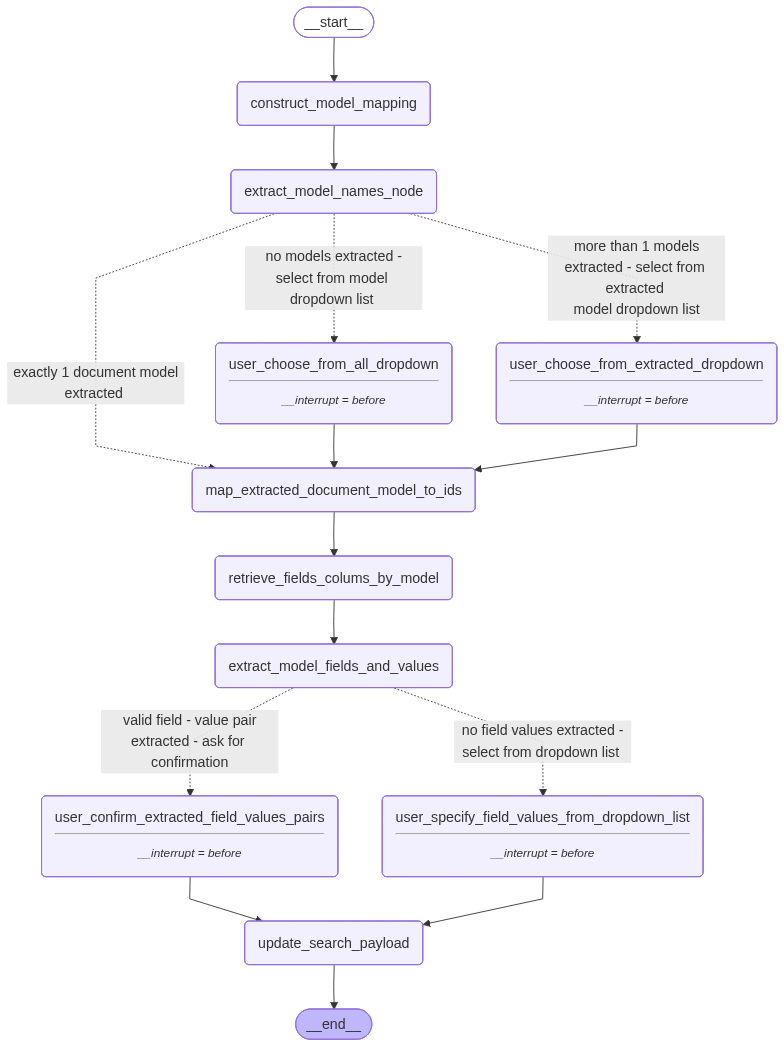

In [126]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

doc_model_builder = StateGraph(state_schema=DocumentModelOverallState)

# add node
doc_model_builder.add_node("construct_model_mapping", construct_model_mapping)
doc_model_builder.add_node("extract_model_names_node", extract_model_names_node)
doc_model_builder.add_node(
    "user_choose_from_all_dropdown", user_choose_from_all_dropdown
)
doc_model_builder.add_node(
    "user_choose_from_extracted_dropdown", user_choose_from_extracted_dropdown
)
doc_model_builder.add_node(
    "retrieve_fields_colums_by_model", retrieve_fields_colums_by_model
)
doc_model_builder.add_node(
    "map_extracted_document_model_to_ids", map_extracted_document_model_to_ids
)
doc_model_builder.add_node(
    "extract_model_fields_and_values", extract_model_fields_and_values
)
doc_model_builder.add_node(
    "user_specify_field_values_from_dropdown_list", user_specify_field_values_from_dropdown_list
)
doc_model_builder.add_node(
    "user_confirm_extracted_field_values_pairs", user_confirm_extracted_field_values_pairs
)
doc_model_builder.add_node(
    "update_search_payload", update_search_payload
)

# add edges
doc_model_builder.add_edge(START, "construct_model_mapping")
doc_model_builder.add_edge("construct_model_mapping", "extract_model_names_node")

doc_model_builder.add_conditional_edges(
    "extract_model_names_node",
    routing_based_on_extracted_documents_models,
    {
        "no models extracted - select from model dropdown list": "user_choose_from_all_dropdown",
        "more than 1 models extracted - select from extracted model dropdown list": "user_choose_from_extracted_dropdown",
        "exactly 1 document model extracted": "map_extracted_document_model_to_ids",
    },
)
doc_model_builder.add_edge("user_choose_from_all_dropdown", "map_extracted_document_model_to_ids")
doc_model_builder.add_edge(
    "user_choose_from_extracted_dropdown", "map_extracted_document_model_to_ids"
)
doc_model_builder.add_edge(
    "map_extracted_document_model_to_ids", "retrieve_fields_colums_by_model"
)
doc_model_builder.add_edge("retrieve_fields_colums_by_model", "extract_model_fields_and_values")
doc_model_builder.add_conditional_edges(
    "extract_model_fields_and_values",
    routing_based_on_extracted_field_value_pairs,
    {
        "no field values extracted - select from dropdown list": "user_specify_field_values_from_dropdown_list",
        "valid field - value pair extracted - ask for confirmation": "user_confirm_extracted_field_values_pairs",
    },
)
doc_model_builder.add_edge("user_specify_field_values_from_dropdown_list", "update_search_payload")
doc_model_builder.add_edge("user_confirm_extracted_field_values_pairs", "update_search_payload")
doc_model_builder.add_edge("update_search_payload", END)


# Compile
memory = MemorySaver()
graph = doc_model_builder.compile(
    interrupt_before=[
        "user_choose_from_all_dropdown",
        "user_choose_from_extracted_dropdown",
        "user_specify_field_values_from_dropdown_list",
        "user_confirm_extracted_field_values_pairs"
    ],
    checkpointer=memory,
)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [127]:
thread = {"configurable": {"thread_id": "1"}}

graph.invoke(
    {
        "messages": [
            HumanMessage(content="Search all documents in invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank")
        ],
        "search_attributes": ["queue","document_model"],
    },
    thread,
)


💡 I am making GraphQL call to fetch model names and ids
Status Code: 200
data:  {'data': {'models': [{'id': 21, 'name': 'ERG new Model', '__typename': 'Model'}, {'id': 44, 'name': 'Testmodel', '__typename': 'Model'}, {'id': 62, 'name': 'Excel Doc Test', '__typename': 'Model'}, {'id': 63, 'name': 'mergetestmodel', '__typename': 'Model'}, {'id': 64, 'name': 'financial statements', '__typename': 'Model'}, {'id': 67, 'name': 'Address Test Model', '__typename': 'Model'}, {'id': 68, 'name': 'TableTest', '__typename': 'Model'}, {'id': 69, 'name': 'STengTables', '__typename': 'Model'}, {'id': 77, 'name': 'Checkbox Improvement', '__typename': 'Model'}, {'id': 78, 'name': 'BankStat', '__typename': 'Model'}, {'id': 93, 'name': 'Table Detection', '__typename': 'Model'}, {'id': 99, 'name': 'Constellation Test', '__typename': 'Model'}, {'id': 110, 'name': 'RohitModel', '__typename': 'Model'}, {'id': 117, 'name': 'Telescope Test', '__typename': 'Model'}, {'id': 118, 'name': 'ConstTest NSMR 26.05.21'

{'messages': [HumanMessage(content='Search all documents in invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank', additional_kwargs={}, response_metadata={}, id='b81c4048-0b1e-4cfe-8f5a-19c699c90438'),
  AIMessage(content="The user query mentions 'invoice model,' which clearly indicates a request to search within the 'Invoice' model. There are no other model names or variations mentioned in the query.", additional_kwargs={}, response_metadata={}, id='fbde4405-2858-48d2-b163-5a604fb341b6'),
  AIMessage(content="The query specifies 'Invoice number is 34ictgh789', 'Invoice date is 25th November 2025', and 'Customer Name is DBS Bank', which match the fields 'Invoice Number', 'Invoice Date', and 'Customer Name' respectively in the available fields list.", additional_kwargs={}, response_metadata={}, id='2940443a-ec72-4675-8c6c-ee25445aad23')],
 'search_attributes': ['queue', 'document_model'],
 'search_payload': {},
 'map_docum

In [128]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Search all documents in invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank', additional_kwargs={}, response_metadata={}, id='b81c4048-0b1e-4cfe-8f5a-19c699c90438'), AIMessage(content="The user query mentions 'invoice model,' which clearly indicates a request to search within the 'Invoice' model. There are no other model names or variations mentioned in the query.", additional_kwargs={}, response_metadata={}, id='fbde4405-2858-48d2-b163-5a604fb341b6'), AIMessage(content="The query specifies 'Invoice number is 34ictgh789', 'Invoice date is 25th November 2025', and 'Customer Name is DBS Bank', which match the fields 'Invoice Number', 'Invoice Date', and 'Customer Name' respectively in the available fields list.", additional_kwargs={}, response_metadata={}, id='2940443a-ec72-4675-8c6c-ee25445aad23')], 'search_attributes': ['queue', 'document_model'], 'search_payload': 

In [129]:
state.next

('user_confirm_extracted_field_values_pairs',)

In [130]:
graph.invoke(None, thread)


 🚀 I am in update_search_payload node


{'messages': [HumanMessage(content='Search all documents in invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank', additional_kwargs={}, response_metadata={}, id='b81c4048-0b1e-4cfe-8f5a-19c699c90438'),
  AIMessage(content="The user query mentions 'invoice model,' which clearly indicates a request to search within the 'Invoice' model. There are no other model names or variations mentioned in the query.", additional_kwargs={}, response_metadata={}, id='fbde4405-2858-48d2-b163-5a604fb341b6'),
  AIMessage(content="The query specifies 'Invoice number is 34ictgh789', 'Invoice date is 25th November 2025', and 'Customer Name is DBS Bank', which match the fields 'Invoice Number', 'Invoice Date', and 'Customer Name' respectively in the available fields list.", additional_kwargs={}, response_metadata={}, id='2940443a-ec72-4675-8c6c-ee25445aad23')],
 'search_attributes': ['queue'],
 'search_payload': {'others': {'doctype': 'Invoice',

In [131]:
thread = {"configurable": {"thread_id": "2"}}

graph.invoke(
    {
        "messages": [
            HumanMessage(content="Search all documents in invoice model and testinvoice model")
        ],
        "search_attributes": ["queue"],
    },
    thread,
)


💡 I am making GraphQL call to fetch model names and ids
Status Code: 200
data:  {'data': {'models': [{'id': 21, 'name': 'ERG new Model', '__typename': 'Model'}, {'id': 44, 'name': 'Testmodel', '__typename': 'Model'}, {'id': 62, 'name': 'Excel Doc Test', '__typename': 'Model'}, {'id': 63, 'name': 'mergetestmodel', '__typename': 'Model'}, {'id': 64, 'name': 'financial statements', '__typename': 'Model'}, {'id': 67, 'name': 'Address Test Model', '__typename': 'Model'}, {'id': 68, 'name': 'TableTest', '__typename': 'Model'}, {'id': 69, 'name': 'STengTables', '__typename': 'Model'}, {'id': 77, 'name': 'Checkbox Improvement', '__typename': 'Model'}, {'id': 78, 'name': 'BankStat', '__typename': 'Model'}, {'id': 93, 'name': 'Table Detection', '__typename': 'Model'}, {'id': 99, 'name': 'Constellation Test', '__typename': 'Model'}, {'id': 110, 'name': 'RohitModel', '__typename': 'Model'}, {'id': 117, 'name': 'Telescope Test', '__typename': 'Model'}, {'id': 118, 'name': 'ConstTest NSMR 26.05.21'

{'messages': [HumanMessage(content='Search all documents in invoice model and testinvoice model', additional_kwargs={}, response_metadata={}, id='c69a88c2-a719-4c30-927a-a8ea2aebd761'),
  AIMessage(content="The query mentions 'invoice model' and 'testinvoice model'. 'Invoice' is an exact match in the available models. 'testinvoice' does not have a direct or partial match in the available models.", additional_kwargs={}, response_metadata={}, id='8021546d-9858-4288-b13c-4556fb6db8a3'),
  AIMessage(content='The query does not mention any specific fields or values to extract, and it only references models, which do not match any available fields.', additional_kwargs={}, response_metadata={}, id='51be7934-5187-47ad-941f-63f90fa33bac')],
 'search_attributes': ['queue'],
 'search_payload': {},
 'map_document_models_to_ids': {'ERG new Model': '21',
  'Testmodel': '44',
  'Excel Doc Test': '62',
  'mergetestmodel': '63',
  'financial statements': '64',
  'Address Test Model': '67',
  'TableTest

In [132]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Search all documents in invoice model and testinvoice model', additional_kwargs={}, response_metadata={}, id='c69a88c2-a719-4c30-927a-a8ea2aebd761'), AIMessage(content="The query mentions 'invoice model' and 'testinvoice model'. 'Invoice' is an exact match in the available models. 'testinvoice' does not have a direct or partial match in the available models.", additional_kwargs={}, response_metadata={}, id='8021546d-9858-4288-b13c-4556fb6db8a3'), AIMessage(content='The query does not mention any specific fields or values to extract, and it only references models, which do not match any available fields.', additional_kwargs={}, response_metadata={}, id='51be7934-5187-47ad-941f-63f90fa33bac')], 'search_attributes': ['queue'], 'search_payload': {}, 'map_document_models_to_ids': {'ERG new Model': '21', 'Testmodel': '44', 'Excel Doc Test': '62', 'mergetestmodel': '63', 'financial statements': '64', 'Address Test Model': '67', 'TableTe

In [133]:
state.next

('user_specify_field_values_from_dropdown_list',)

In [134]:
graph.update_state(
    thread,
    {
        "extracted_document_models": ["Invoice"]
    },
)


 🚀 I am in routing_based_on_extracted_documents_models
map_fields_to_values:  []
there are no valid field values extracted from user query - show a list of field drop down and ask user to enter value


{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0d43a2-450c-6aba-8006-bf5c61df5b39'}}

In [135]:
graph.invoke(None, thread)


 🚀 I am in update_search_payload node


{'messages': [HumanMessage(content='Search all documents in invoice model and testinvoice model', additional_kwargs={}, response_metadata={}, id='c69a88c2-a719-4c30-927a-a8ea2aebd761'),
  AIMessage(content="The query mentions 'invoice model' and 'testinvoice model'. 'Invoice' is an exact match in the available models. 'testinvoice' does not have a direct or partial match in the available models.", additional_kwargs={}, response_metadata={}, id='8021546d-9858-4288-b13c-4556fb6db8a3'),
  AIMessage(content='The query does not mention any specific fields or values to extract, and it only references models, which do not match any available fields.', additional_kwargs={}, response_metadata={}, id='51be7934-5187-47ad-941f-63f90fa33bac')],
 'search_attributes': ['queue'],
 'search_payload': {'others': {'doctype': 'Invoice', 'fields': []}},
 'map_document_models_to_ids': {'ERG new Model': '21',
  'Testmodel': '44',
  'Excel Doc Test': '62',
  'mergetestmodel': '63',
  'financial statements': '6